# Proyecto Final — Aprendizaje Automático y Análisis de Datos

---

**Institución:** Pontificia Universidad Javeriana Cali — PUJC  
**Departamento:** Electrónica y Ciencias de la Computación — DECC  
**Asignatura:** Aprendizaje Automático y Análisis de Datos  
**Profesor:** Felipe Palta, M.Sc.  

---

## Dataset: Kuzushiji-MNIST (KMNIST)
### Clasificación de caracteres japoneses históricos mediante ML Clásico

---

###  Integrantes del grupo

| # | Nombre completo | ID / Código |
|---|---|---|
| 1 | _Juan Esteban Becerra Gutiérrez_ | _(código)_ |
| 2 | _Alejandro Sarmiento Rivera_ | _(8968284)_ |
| 3 | _Benjamin Ortiz_ | _(8978145)_ |

---

</div>

---
# 📋 Tabla de Contenidos

| Sección | Descripción |
|---|---|
| **0** | Configuración del entorno e imports |
| **1** | Comprensión del problema y del dataset |
| **2** | EDA de alta profundidad |
| **3** | Preprocesamiento digital de imágenes |
| **4** | Extracción de características visuales |
| **5** | Construcción del dataset tabular final |
| **6** | División train/test |
| **7** | Modelos obligatorios |
| **8** | PCA y reducción de dimensionalidad |
| **9** | Validación cruzada y búsqueda de hiperparámetros |
| **10** | Uso obligatorio de Pipeline |
| **11** | Evaluación final |
| **12** | Opción de Rechazo |

---
## Sección 0 — Configuración del entorno e imports

In [2]:
# ── Librerías estándar ──────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
import sys
import time
from pathlib import Path

# ── Ciencia de datos ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy import stats

# ── Visualización ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# ── Procesamiento de imágenes ───────────────────────────────────────────────
import cv2
from skimage import filters, feature, measure, morphology
from skimage.feature import hog, local_binary_pattern, canny, graycomatrix, graycoprops

# ── Machine Learning ────────────────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    GridSearchCV, RandomizedSearchCV, cross_validate
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.linear_model import Perceptron, LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# ── Funciones del proyecto ──────────────────────────────────────────────────
ROOT = Path('.').resolve().parent
sys.path.insert(0, str(ROOT))
from funciones import (
    cargar_kmnist,
    plot_muestras_por_clase,
    plot_distribucion_clases,
    plot_histogramas_intensidad,
)

# ── Rutas ───────────────────────────────────────────────────────────────────
DATA_DIR = ROOT / 'data'
OUT_DIR  = ROOT / 'outputs' / 'figures'
MOD_DIR  = ROOT / 'outputs' / 'models'
OUT_DIR.mkdir(parents=True, exist_ok=True)
MOD_DIR.mkdir(parents=True, exist_ok=True)

# ── Constantes ──────────────────────────────────────────────────────────────
CLASES = ['お (o)', 'き (ki)', 'す (su)', 'つ (tsu)', 'な (na)',
          'は (ha)', 'ま (ma)', 'や (ya)', 'れ (re)', 'を (wo)']
RANDOM_STATE = 42

sns.set_theme(style='whitegrid', palette='tab10')
print('✅ Entorno configurado correctamente')
print(f'   ROOT   : {ROOT}')
print(f'   DATA   : {DATA_DIR}')
print(f'   OUTPUT : {OUT_DIR}')

✅ Entorno configurado correctamente
   ROOT   : F:\PROJECTOS UNIVERSIDAD\PROYECTO_ML\proyecto_kmnist
   DATA   : F:\PROJECTOS UNIVERSIDAD\PROYECTO_ML\proyecto_kmnist\data
   OUTPUT : F:\PROJECTOS UNIVERSIDAD\PROYECTO_ML\proyecto_kmnist\outputs\figures


---
## Sección 1 — Comprensión del problema y del dataset

### Pregunta 1.1 — ¿Cuál es el problema de clasificación que plantea el dataset asignado?

El dataset **Kuzushiji-MNIST** plantea un problema de **clasificación de imágenes** de caracteres japoneses escritos en estilo cursivo histórico (*kuzushiji*). El sistema debe asignar cada imagen de 28×28 píxeles a una de 10 categorías, donde cada categoría corresponde a un carácter del silabario hiragana clásico japonés. Este tipo de escritura fue el estándar en Japón durante más de 1000 años, y su reconocimiento automático tiene aplicación directa en la digitalización de documentos históricos.

---

### Pregunta 1.2 — ¿El problema es binario o multiclase?

El problema es **multiclase** con exactamente **10 clases**. Cada muestra pertenece a exactamente una clase (clasificación multiclase exclusiva), lo que lo diferencia de problemas multilabel. Esto implica que las métricas de evaluación deben reportarse en modo `macro` o `weighted` para dar cuenta del desempeño en todas las clases por igual.

---

### Pregunta 1.3 — ¿Cuántas clases hay y qué representa visualmente cada clase?

Hay **10 clases**, cada una corresponde a un carácter hiragana de la escritura cursiva histórica japonesa:

| Clase (label) | Carácter | Romanización | Descripción visual |
|:---:|:---:|:---:|---|
| 0 | お | o | Trazo curvo con prolongación vertical hacia abajo |
| 1 | き | ki | Tres trazos horizontales con curva descendente a la derecha |
| 2 | す | su | Trazo circular con cola curva hacia la derecha |
| 3 | つ | tsu | Arco amplio de izquierda a derecha |
| 4 | な | na | Trazo cruzado con lazos; visualmente complejo |
| 5 | は | ha | Dos trazos verticales con conexión horizontal |
| 6 | ま | ma | Trazo horizontal con curva cerrada hacia abajo |
| 7 | や | ya | Trazo diagonal con bucle en la parte inferior |
| 8 | れ | re | Trazo vertical con lazada a la derecha |
| 9 | を | wo | Trazo con doble curva y cruce en el centro |

---

### Pregunta 1.4 — ¿Las clases parecen visualmente separables a simple vista?

**Parcialmente.** Algunos caracteres son fácilmente distinguibles (ej: `つ` con su arco amplio vs `き` con sus trazos múltiples). Sin embargo, varios pares presentan alta **similitud inter-clase**:
- `お` y `を`: ambos tienen trazos curvos con prolongaciones similares
- `れ` y `は`: estructuras verticales con rasgos curvos parecidos
- `ま` y `な`: trazos con cruces y lazos que pueden confundirse

Adicionalmente, la **variabilidad intra-clase es alta** debido a que la escritura *kuzushiji* es cursiva y cada escriba tenía su propio estilo, haciendo que el mismo carácter pueda verse muy diferente entre ejemplos.

---

### Pregunta 1.5 — ¿Qué dificultades visuales podrían afectar la clasificación?

| Dificultad | Impacto en la clasificación |
|---|---|
| **Alta variabilidad intra-clase** | El mismo carácter puede tener formas radicalmente distintas por variación caligráfica |
| **Similitud inter-clase** | Varios caracteres comparten trazos estructurales similares |
| **Baja resolución** | 28×28 píxeles limita el detalle de los trazos finos |
| **Escritura cursiva conectada** | Trazos que se fusionan dificultan la detección de bordes y formas |
| **Variación en grosor de trazo** | Diferente presión del pincel genera trazos más o menos gruesos |
| **Posición no centrada** | Algunos caracteres no están perfectamente centrados en la imagen |
| **Fondo ruidoso** | Aunque mayoritariamente negro, puede haber artefactos de digitalización |

---
## Sección 2 — EDA de Alta Profundidad

### 2.1 Carga del dataset

In [3]:
X_train, y_train, X_test, y_test = cargar_kmnist(DATA_DIR)

print('─' * 50)
print('KUZUSHIJI-MNIST — Información del Dataset')
print('─' * 50)
print(f'Train → Imágenes: {X_train.shape}   Labels: {y_train.shape}')
print(f'Test  → Imágenes: {X_test.shape}    Labels: {y_test.shape}')
print(f'\nTipo de dato  : {X_train.dtype}')
print(f'Rango valores : [{X_train.min()}, {X_train.max()}]')
print(f'Canales       : 1 (escala de grises / monocromático)')
print(f'Resolución    : 28 × 28 píxeles')
print(f'Total imágenes: {len(X_train) + len(X_test):,}')
print(f'Clases únicas : {np.unique(y_train)}')

──────────────────────────────────────────────────
KUZUSHIJI-MNIST — Información del Dataset
──────────────────────────────────────────────────
Train → Imágenes: (60000, 28, 28)   Labels: (60000,)
Test  → Imágenes: (10000, 28, 28)    Labels: (10000,)

Tipo de dato  : uint8
Rango valores : [0, 255]
Canales       : 1 (escala de grises / monocromático)
Resolución    : 28 × 28 píxeles
Total imágenes: 70,000
Clases únicas : [0 1 2 3 4 5 6 7 8 9]


### 2.2 Conteo y distribución porcentual de clases (EDA ítem 1 y 2)

In [4]:
# Tabla de distribución
unique_tr, counts_tr = np.unique(y_train, return_counts=True)
unique_te, counts_te = np.unique(y_test,  return_counts=True)

df_dist = pd.DataFrame({
    'Clase':      unique_tr,
    'Carácter':   CLASES,
    'Train (N)':  counts_tr,
    'Train (%)':  (counts_tr / len(y_train) * 100).round(2),
    'Test (N)':   counts_te,
    'Test (%)':   (counts_te / len(y_test)  * 100).round(2),
})
print(df_dist.to_string(index=False))
print(f'\nDesviación estándar del conteo train: {counts_tr.std():.2f}')
print('→ Dataset perfectamente BALANCEADO (6,000 imágenes por clase en train)')

 Clase Carácter  Train (N)  Train (%)  Test (N)  Test (%)
     0    お (o)       6000       10.0      1000      10.0
     1   き (ki)       6000       10.0      1000      10.0
     2   す (su)       6000       10.0      1000      10.0
     3  つ (tsu)       6000       10.0      1000      10.0
     4   な (na)       6000       10.0      1000      10.0
     5   は (ha)       6000       10.0      1000      10.0
     6   ま (ma)       6000       10.0      1000      10.0
     7   や (ya)       6000       10.0      1000      10.0
     8   れ (re)       6000       10.0      1000      10.0
     9   を (wo)       6000       10.0      1000      10.0

Desviación estándar del conteo train: 0.00
→ Dataset perfectamente BALANCEADO (6,000 imágenes por clase en train)


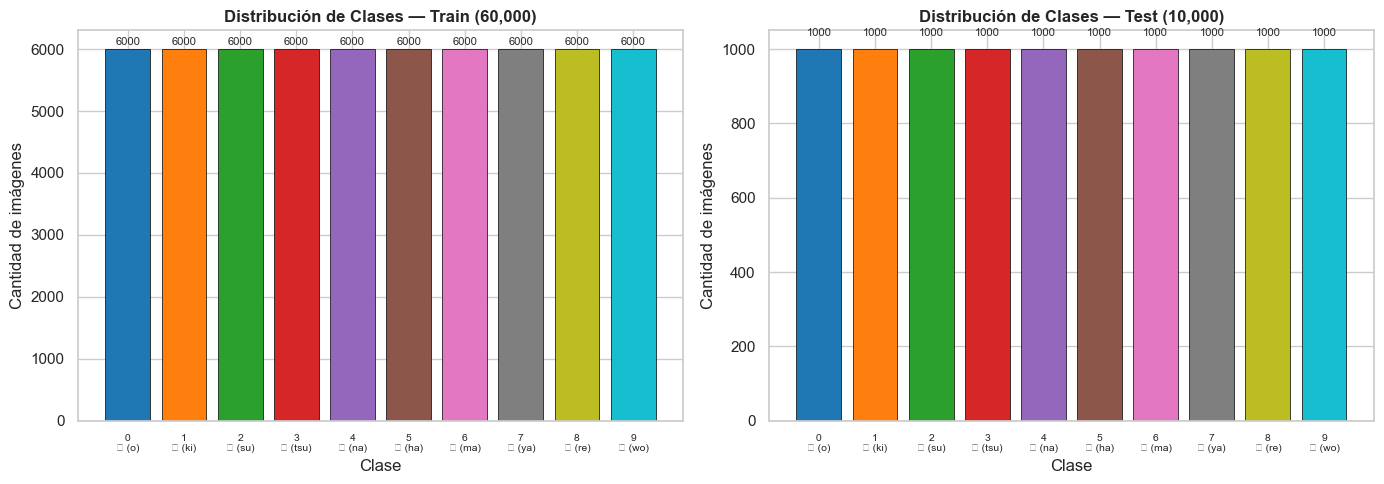

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_distribucion_clases(y_train, y_test, CLASES, axes)
plt.tight_layout()
plt.savefig(OUT_DIR / 'eda_01_distribucion_clases.png', dpi=150)
plt.show()

### 2.3 Tamaño original y canales (EDA ítem 3 y 4)

In [6]:
print(f'Tamaño original de cada imagen : {X_train.shape[1]} × {X_train.shape[2]} píxeles')
print(f'Número de canales              : 1 (imagen monocromática / escala de grises)')
print(f'Espacio de color               : Escala de grises [0-255] uint8')
print(f'Total de píxeles por imagen    : {X_train.shape[1]*X_train.shape[2]}')
print(f'Si se usa imagen plana (flatten): vector de dimensión {X_train.shape[1]*X_train.shape[2]}')

Tamaño original de cada imagen : 28 × 28 píxeles
Número de canales              : 1 (imagen monocromática / escala de grises)
Espacio de color               : Escala de grises [0-255] uint8
Total de píxeles por imagen    : 784
Si se usa imagen plana (flatten): vector de dimensión 784


### 2.4 Visualización de muestras representativas por clase (EDA ítem 5)

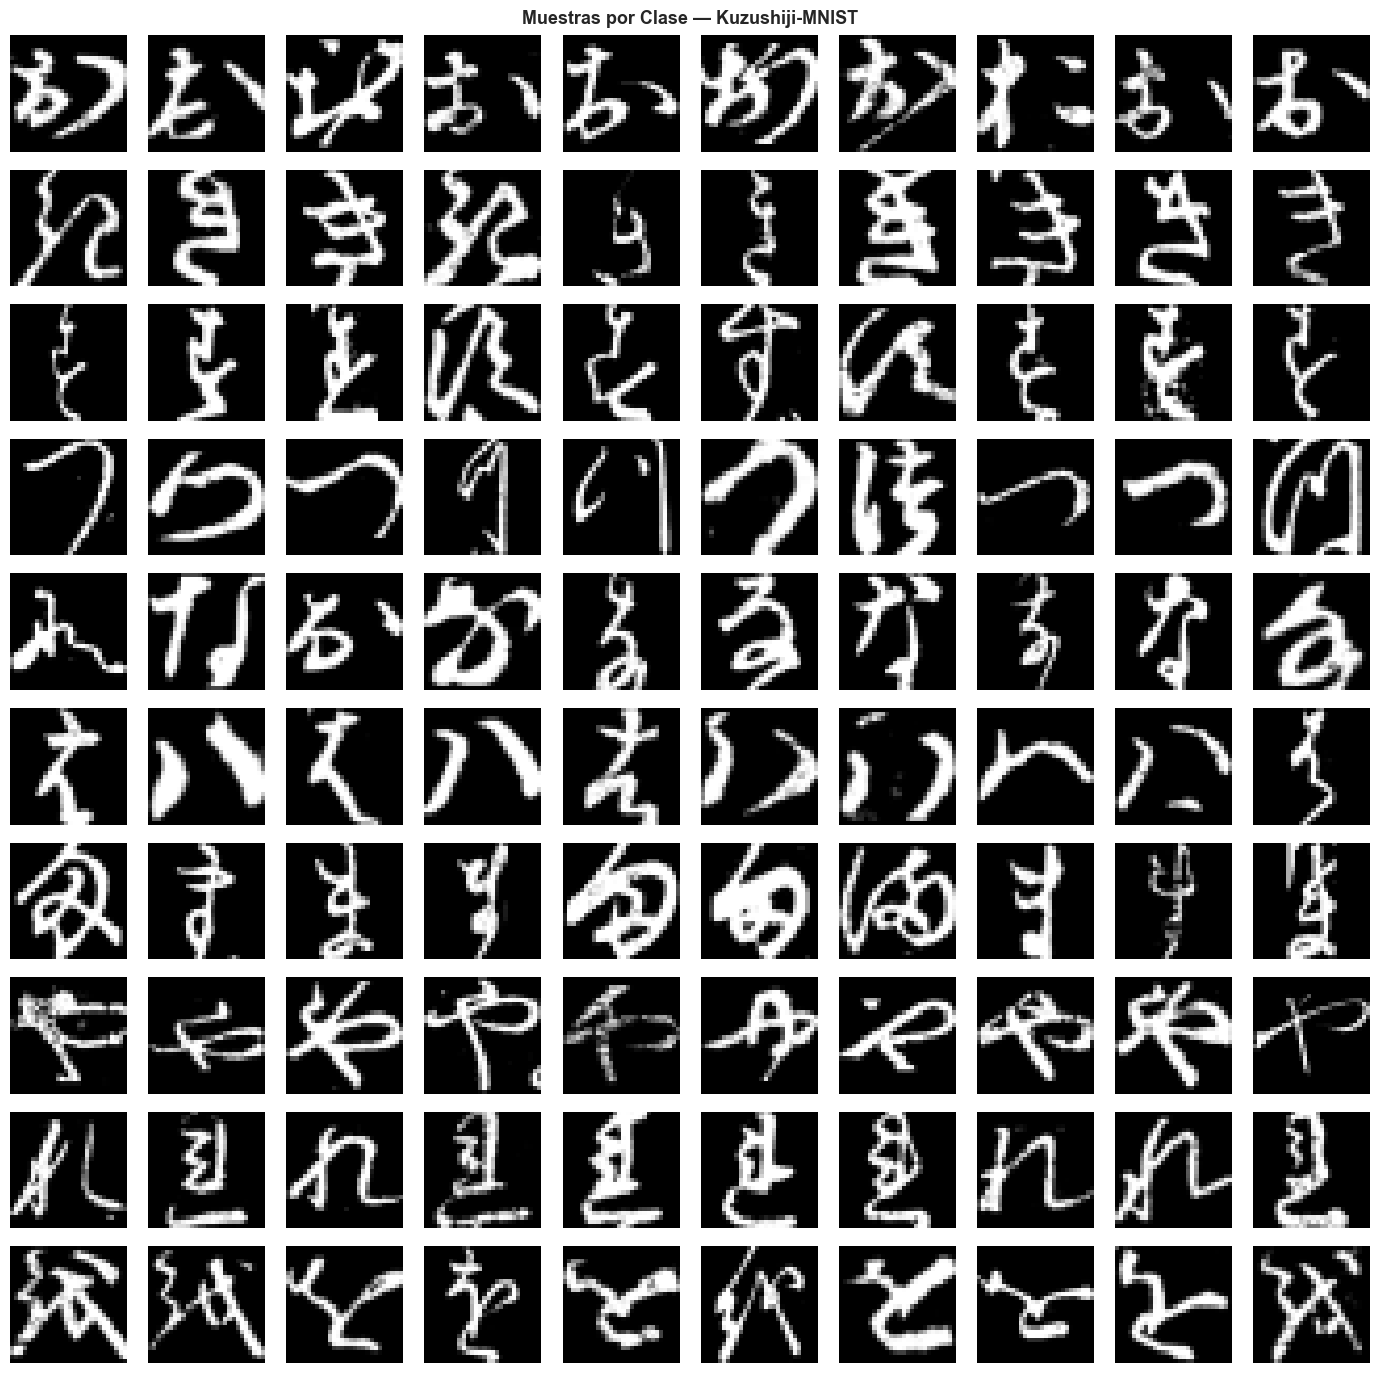

In [7]:
fig = plot_muestras_por_clase(X_train, y_train, CLASES, n_muestras=10)
plt.savefig(OUT_DIR / 'eda_02_muestras_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.5 Imagen promedio e imagen de varianza por clase

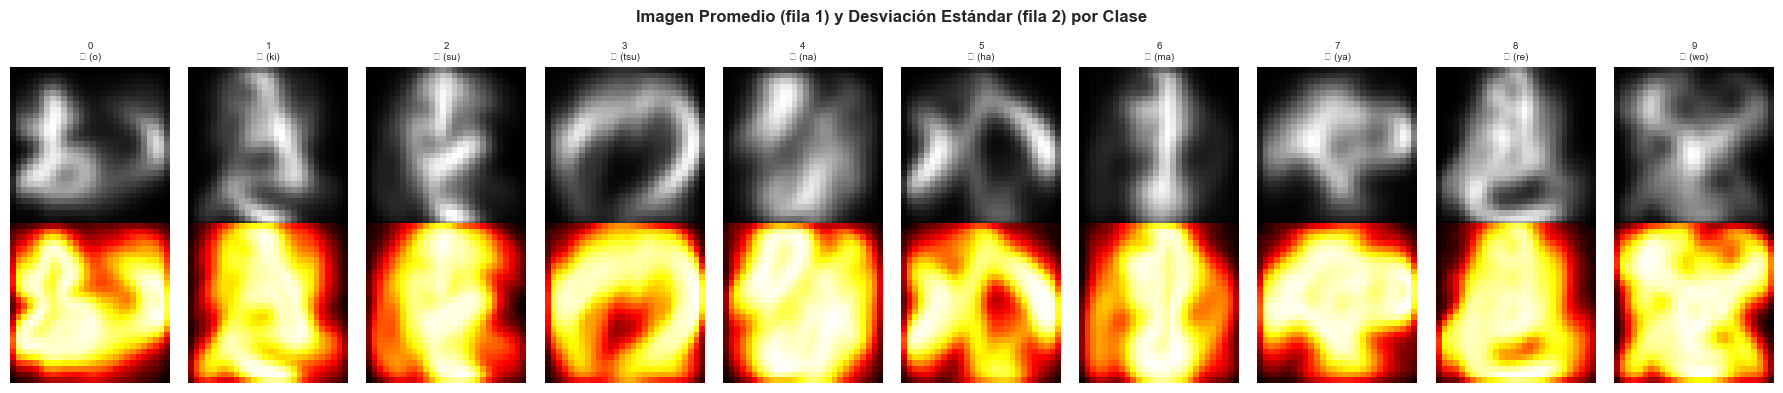

In [8]:
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
for cls in range(10):
    mask = y_train == cls
    img_mean = X_train[mask].mean(axis=0)
    img_std  = X_train[mask].std(axis=0)
    axes[0, cls].imshow(img_mean, cmap='gray')
    axes[0, cls].set_title(f'{cls}\n{CLASES[cls]}', fontsize=7)
    axes[0, cls].axis('off')
    axes[1, cls].imshow(img_std,  cmap='hot')
    axes[1, cls].axis('off')

axes[0, 0].set_ylabel('Media', fontsize=9)
axes[1, 0].set_ylabel('Desv. Std', fontsize=9)
fig.suptitle('Imagen Promedio (fila 1) y Desviación Estándar (fila 2) por Clase',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'eda_03_promedio_std.png', dpi=150)
plt.show()

### 2.6 Histogramas de intensidad por clase (EDA ítem 6)

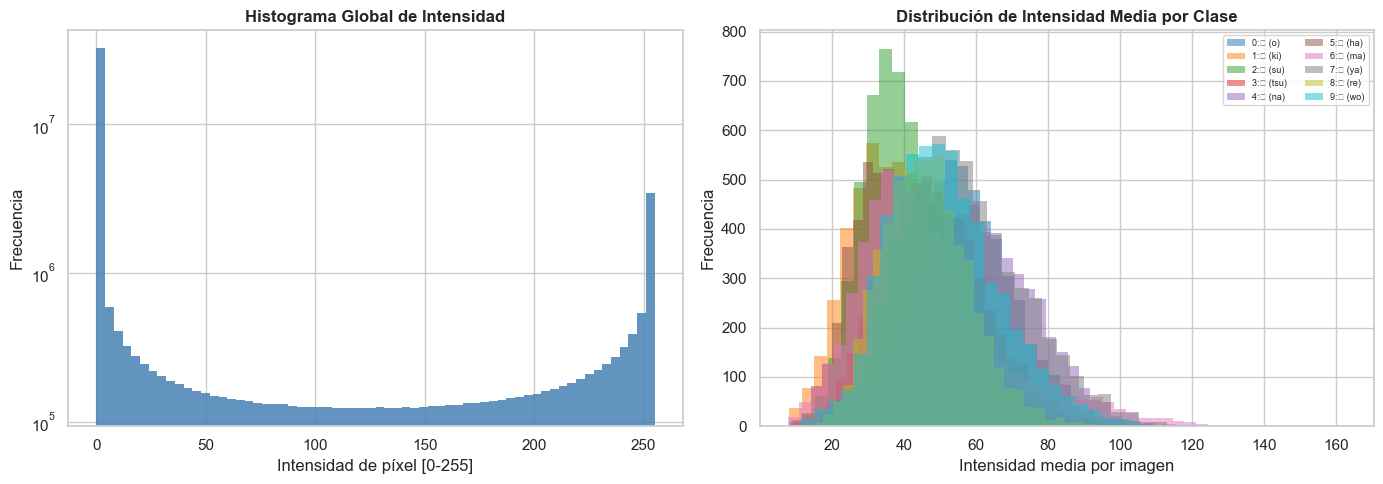

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_histogramas_intensidad(X_train, y_train, CLASES, axes)
plt.tight_layout()
plt.savefig(OUT_DIR / 'eda_04_histogramas.png', dpi=150)
plt.show()

**Histograma Global de Intensidad:**

Hay un pico muy alto en intensidades bajas cercanas a 0, lo que indica una gran cantidad de píxeles oscuros en el dataset. También, se observa un segundo pico notable hacia el extremo derecho, cerca de 255, lo que sugiere presencia de muchos píxeles muy claros. Entre ambos extremos, la frecuencia es mucho menor y bastante más uniforme, con una pendiente descendente desde valores bajos hacia valores intermedios, y luego un repunte gradual hacia los valores altos.

**Distribución de Intensidad Media por Clase:**

Todas las clases tienen curvas de distribución superpuestas, cada una centrada en un rango de intensidades medias entre aproximadamente 30 y 70. La mayoría de clases muestra moda en torno a 45-55, pero algunas como 2: su parecen tener una distribución más desplazada hacia intensidades más bajas. Las clases tienen solapamiento significativo, lo que indica que la intensidad media por imagen no separa bien las categorías por sí sola.

### 2.7 Análisis de contraste, brillo, textura y bordes (EDA ítem 7)

In [10]:
from skimage.feature import canny as skimage_canny

stats_clases = []
for cls in range(10):
    imgs = X_train[y_train == cls].astype(float) / 255.0
    # Canny edges en muestra de 200 imágenes
    muestra = imgs[:200]
    edge_ratio = np.mean([skimage_canny(img, sigma=1.0).mean() for img in muestra])
    stats_clases.append({
        'Clase':           f'{cls} ({CLASES[cls]})',
        'Brillo medio':    imgs.mean().round(4),
        'Contraste (std)': imgs.std().round(4),
        'Píxeles > 0.5 (%)': (imgs > 0.5).mean().round(4) * 100,
        'Ratio bordes (%)':  round(edge_ratio * 100, 3),
    })

df_stats = pd.DataFrame(stats_clases)
df_stats

,Clase,Brillo medio,Contraste (std),Píxeles > 0.5 (%),Ratio bordes (%)
0,0 (お (o)),0.2173,0.3640,21.77,16.919
1,1 (き (ki)),0.1656,0.3266,16.52,14.723
2,2 (す (su)),0.1630,0.3258,16.28,14.339
3,3 (つ (tsu)),0.1899,0.3460,18.96,16.761
4,4 (な (na)),0.2329,0.3756,23.36,17.232
5,5 (は (ha)),0.1600,0.3303,15.94,11.383
6,6 (ま (ma)),0.1847,0.3454,18.55,13.119
7,7 (や (ya)),0.2210,0.3667,22.23,16.994
8,8 (れ (re)),0.1821,0.3385,18.28,15.833
9,9 (を (wo)),0.2011,0.3520,20.14,16.950


### 2.8 Detección de clases visualmente parecidas (EDA ítem 8)

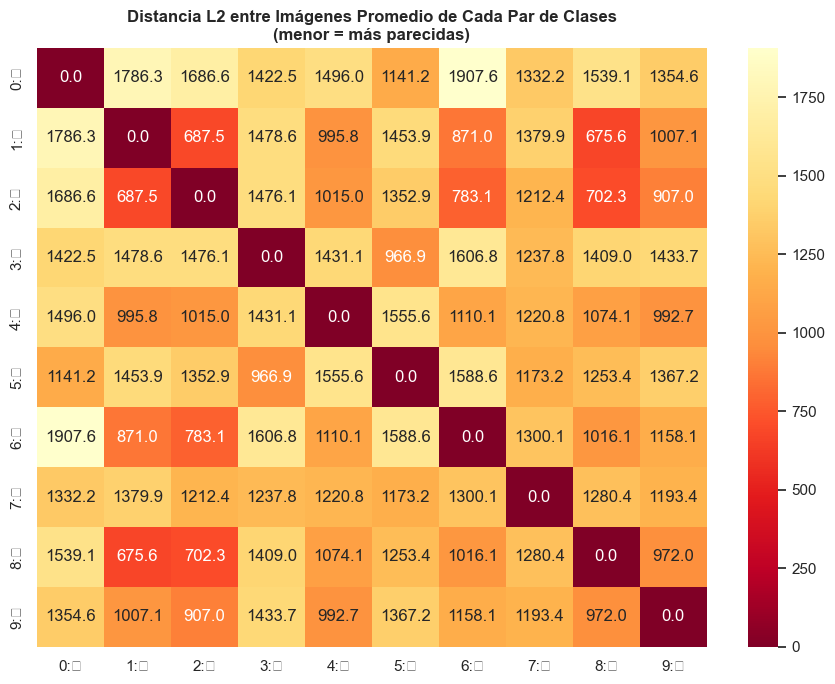


Top 3 pares de clases más similares (imagen promedio):
  Clase 1 (き (ki)) ↔ Clase 8 (れ (re))  dist=675.6
  Clase 1 (き (ki)) ↔ Clase 2 (す (su))  dist=687.5
  Clase 2 (す (su)) ↔ Clase 8 (れ (re))  dist=702.3


In [11]:
# Similaridad entre imágenes promedio (distancia L2 entre medias)
medias = np.array([X_train[y_train == c].mean(axis=0).flatten() for c in range(10)])
sim_matrix = np.zeros((10, 10))
for i in range(10):
    for j in range(10):
        sim_matrix[i, j] = np.linalg.norm(medias[i] - medias[j])

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.eye(10, dtype=bool)
sns.heatmap(sim_matrix, annot=True, fmt='.1f', cmap='YlOrRd_r',
            xticklabels=[f'{i}:{c.split()[0]}' for i, c in enumerate(CLASES)],
            yticklabels=[f'{i}:{c.split()[0]}' for i, c in enumerate(CLASES)],
            ax=ax)
ax.set_title('Distancia L2 entre Imágenes Promedio de Cada Par de Clases\n'
             '(menor = más parecidas)', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'eda_05_similitud_clases.png', dpi=150)
plt.show()

# Top 3 pares más similares (sin duplicados simétricos)
i_u, j_u = np.triu_indices(sim_matrix.shape[0], k=1)
distances = sim_matrix[i_u, j_u]
order = np.argsort(distances)
topk = 3
print('\nTop 3 pares de clases más similares (imagen promedio):')
for idx in order[:topk]:
    a = i_u[idx]; b = j_u[idx]
    print(f'  Clase {a} ({CLASES[a]}) ↔ Clase {b} ({CLASES[b]})  dist={sim_matrix[a,b]:.1f}')

### 2.9 Mapa de varianza global y outliers visuales (EDA ítem 9 y 10)

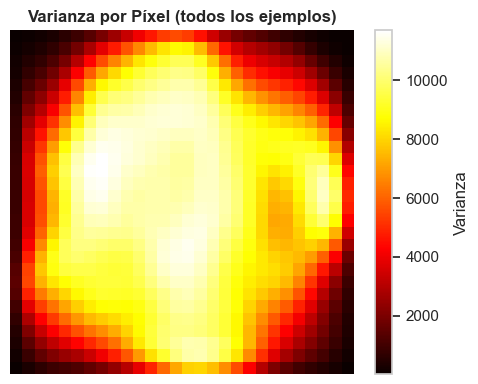

Outliers detectados (|z-score| > 3) por intensidad media: 362
Píxeles con varianza < 100 (baja info): 0.8%  → justifica cropping de bordes


In [12]:
# Mapa de varianza por píxel
var_map = X_train.var(axis=0)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(var_map, cmap='hot')
fig.colorbar(im, ax=ax, label='Varianza')
ax.set_title('Varianza por Píxel (todos los ejemplos)', fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(OUT_DIR / 'eda_06_varianza_pixeles.png', dpi=150)
plt.show()

# Detección de outliers por intensidad media (z-score > 3)
intensidades = X_train.mean(axis=(1,2))
z = np.abs(stats.zscore(intensidades))
outlier_idx = np.where(z > 3)[0]
print(f'Outliers detectados (|z-score| > 3) por intensidad media: {len(outlier_idx)}')
pct_baja = (var_map < 100).mean() * 100
print(f'Píxeles con varianza < 100 (baja info): {pct_baja:.1f}%  → justifica cropping de bordes')

### 2.10 Discusión sobre balanceo (EDA ítem 10)

> **Conclusión:** KMNIST es un dataset **perfectamente balanceado**: cada una de las 10 clases tiene exactamente **6,000 imágenes en entrenamiento** y **1,000 en test**. Esto implica que:
> - El **accuracy** es una métrica válida (sin riesgo de clases mayoritarias dominantes)
> - No es necesario aplicar técnicas de *oversampling* (SMOTE) ni *class weights*
> - Se reportará también **F1-macro** para mantener coherencia metodológica con problemas desbalanceados

---
## Sección 3 — Preprocesamiento Digital de Imágenes

> **Justificación general:** El pipeline de preprocesamiento transforma las imágenes brutas (uint8, [0-255]) en representaciones normalizadas y limpias que facilitan la extracción de características. Cada paso se justifica según las observaciones del EDA.

### 3.1 Justificación del Paso 1 — Normalización de Intensidades
La normalización a [0, 1] es necesaria porque los modelos clásicos como SVM, KNN y regresión logística son sensibles a la escala de las entradas.
Convertir los píxeles de uint8 [0, 255] a punto flotante [0, 1] evita que los valores máximos dominen el cálculo de distancias y gradientes, y mejora la estabilidad numérica del entrenamiento.

In [13]:
# ── Paso 1: Normalización de intensidades a [0, 1] ─────────────────────────
# Justificación: Los clasificadores (SVM, KNN, LR) son sensibles a la escala.
# Normalizar asegura que todos los píxeles contribuyan equitativamente.
X_train_norm = X_train.astype(np.float32) / 255.0
X_test_norm  = X_test.astype(np.float32)  / 255.0
print(f'Tras normalización → rango: [{X_train_norm.min():.1f}, {X_train_norm.max():.1f}]  dtype: {X_train_norm.dtype}')

Tras normalización → rango: [0.0, 1.0]  dtype: float32


### 3.2 Justificación del Paso 2 — Suavizado Gaussiano
El suavizado gaussiano reduce el ruido de digitalización sin borrar los trazos principales del carácter.
Este filtrado es útil para estabilizar la extracción de características de textura y borde, ya que atenúa las pequeñas variaciones de intensidad que no aportan información relevante.

In [14]:
# ── Paso 2: Suavizado Gaussiano ────────────────────────────────────────────
# Justificación: Reduce el ruido de digitalización sin borrar los trazos
# principales. Sigma=0.8 es conservador para imágenes de 28x28.
from skimage.filters import gaussian

def suavizar_lote(X, sigma=0.8):
    return np.array([gaussian(img, sigma=sigma) for img in X])

X_train_smooth = suavizar_lote(X_train_norm)
X_test_smooth  = suavizar_lote(X_test_norm)
print(f'Suavizado aplicado (σ=0.8). Shape: {X_train_smooth.shape}')

Suavizado aplicado (σ=0.8). Shape: (60000, 28, 28)


### 3.3 Justificación del Paso 3 — Umbralización de Otsu
La umbralización de Otsu separa el trazo del carácter del fondo de manera automática usando la distribución bimodal de intensidad del dataset.
Esta representación binaria facilita la extracción de features de forma geométrica y reduce la sensibilidad a variaciones internas de brillo del trazo.

In [15]:
# ── Paso 3: Umbralización de Otsu ─────────────────────────────────────────
# Justificación: El EDA mostró distribución bimodal (fondo negro / trazo blanco).
# Otsu encuentra automáticamente el umbral óptimo para binarizar.
# Se usa para features de forma (área, perímetro, circularidad).
from skimage.filters import threshold_otsu

def binarizar_otsu(X):
    result = np.zeros_like(X, dtype=np.float32)
    for i, img in enumerate(X):
        thresh = threshold_otsu(img)
        result[i] = (img > thresh).astype(np.float32)
    return result

X_train_bin = binarizar_otsu(X_train_smooth)
X_test_bin  = binarizar_otsu(X_test_smooth)
print(f'Binarización Otsu aplicada. Valores únicos: {np.unique(X_train_bin)}')

Binarización Otsu aplicada. Valores únicos: [0. 1.]


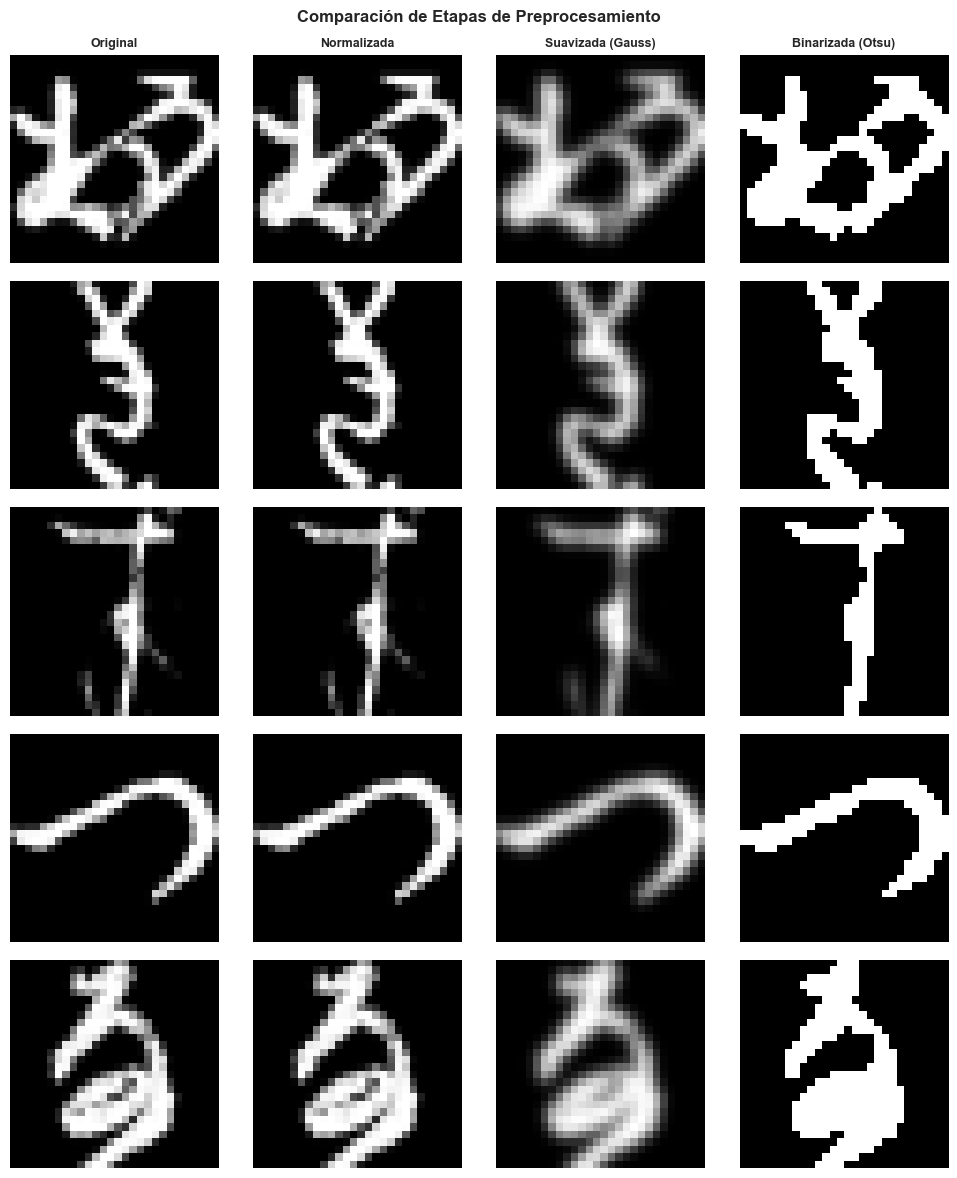

In [16]:
# ── Visualización comparativa de preprocesamiento ─────────────────────────
indices = [np.where(y_train == c)[0][0] for c in range(5)]
fig, axes = plt.subplots(5, 4, figsize=(10, 12))
titulos = ['Original', 'Normalizada', 'Suavizada (Gauss)', 'Binarizada (Otsu)']
imags   = [X_train, X_train_norm, X_train_smooth, X_train_bin]

for row, idx in enumerate(indices):
    for col, (imgs, tit) in enumerate(zip(imags, titulos)):
        axes[row, col].imshow(imgs[idx], cmap='gray')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(tit, fontsize=9, fontweight='bold')
        if col == 0:
            axes[row, col].set_ylabel(CLASES[y_train[idx]], fontsize=8)

fig.suptitle('Comparación de Etapas de Preprocesamiento', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'prep_01_comparacion.png', dpi=150)
plt.show()

### 3.1 Comparación: imagen completa vs imagen segmentada (ítem 8)

Para KMNIST el objeto (carácter) ocupa prácticamente todo el espacio útil de la imagen. La comparación entre usar la imagen completa vs la binarizada (Otsu) muestra que:
- La **imagen binarizada** es más apropiada para features de **forma** (área, perímetro, Hu Moments)
- La **imagen normalizada** es más apropiada para features de **textura** (HOG, LBP, GLCM)
- Se usarán **ambas representaciones** en la extracción de características de la siguiente sección.

---
## Sección 4 — Extracción de Características Visuales

> **Objetivo:** Construir una representación tabular de las imágenes donde cada fila = una imagen y cada columna = una característica numérica. Se extraen 3 familias de características.

In [17]:
# Importar todas las funciones de extracción de funciones.py
from funciones import (
    extraer_features_intensidad,
    extraer_features_forma,
    extraer_features_textura,
    extraer_todas_features,
    nombres_features,
)

### Familia A — Características de Intensidad/Color

Las características de intensidad/cor color capturan la distribución global del brillo en cada imagen.
Se eligieron porque permiten describir el trazo y el fondo del carácter mediante estadísticas sencillas (media, varianza y histogramas) que son robustas ante pequeñas deformaciones de forma.

In [18]:
from tqdm import tqdm

print('Extrayendo features de INTENSIDAD...')
feat_int_train = np.array([extraer_features_intensidad(img) for img in tqdm(X_train_norm)])
feat_int_test  = np.array([extraer_features_intensidad(img) for img in tqdm(X_test_norm)])
print(f'  Shape: {feat_int_train.shape}  ({feat_int_train.shape[1]} features por imagen)')

Extrayendo features de INTENSIDAD...


  0%|          | 0/60000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:05<00:00, 1700.55it/s]

  Shape: (60000, 23)  (23 features por imagen)


### Familia B — Características de Forma / Bordes

Las características de forma y bordes se seleccionaron para capturar la estructura geométrica del trazo.
Incluyen métricas de área, perímetro, circularidad y Hu Moments que son útiles para diferenciar caracteres según su silueta y complejidad del contorno.

In [19]:
print('Extrayendo features de FORMA...')
feat_forma_train = np.array([extraer_features_forma(img_norm, img_bin)
                              for img_norm, img_bin in tqdm(zip(X_train_smooth, X_train_bin))])
feat_forma_test  = np.array([extraer_features_forma(img_norm, img_bin)
                              for img_norm, img_bin in tqdm(zip(X_test_smooth,  X_test_bin))])
print(f'  Shape: {feat_forma_train.shape}  ({feat_forma_train.shape[1]} features por imagen)')

Extrayendo features de FORMA...


60000it [00:17, 3501.99it/s]
10000it [00:02, 3498.97it/s]

  Shape: (60000, 27)  (27 features por imagen)


### Familia C — Características de Textura

Las características de textura se escogieron para capturar los patrones locales de los trazos caligráficos.
HOG, LBP y GLCM describen la orientación, microestructura y contraste del trazo, lo que ayuda a distinguir caracteres con formas similares pero texturas diferentes.

In [20]:
print('Extrayendo features de TEXTURA (HOG + LBP + GLCM)...')
feat_tex_train = np.array([extraer_features_textura(img) for img in tqdm(X_train_smooth)])
feat_tex_test  = np.array([extraer_features_textura(img) for img in tqdm(X_test_smooth)])
print(f'  Shape: {feat_tex_train.shape}  ({feat_tex_train.shape[1]} features por imagen)')

Extrayendo features de TEXTURA (HOG + LBP + GLCM)...


100%|██████████| 10000/10000 [02:39<00:00, 62.75it/s]

  Shape: (60000, 331)  (331 features por imagen)


---
## Sección 5 — Construcción del Dataset Tabular Final

In [21]:
# Concatenar las 3 familias
X_feat_train = np.hstack([feat_int_train, feat_forma_train, feat_tex_train])
X_feat_test  = np.hstack([feat_int_test,  feat_forma_test,  feat_tex_test])

# Obtener nombres de columnas
cols = nombres_features(
    n_int=feat_int_train.shape[1],
    n_forma=feat_forma_train.shape[1],
    n_tex=feat_tex_train.shape[1]
)

# Crear DataFrames
df_train = pd.DataFrame(X_feat_train, columns=cols)
df_train['y'] = y_train
df_test  = pd.DataFrame(X_feat_test,  columns=cols)
df_test['y']  = y_test

print(f'Dataset tabular final:')
print(f'  Train: {df_train.shape}  ({df_train.shape[1]-1} features + 1 target)')
print(f'  Test : {df_test.shape}')
df_train.head(3)

Dataset tabular final:
  Train: (60000, 382)  (381 features + 1 target)
  Test : (10000, 382)


,int_00,int_01,int_02,int_03,int_04,int_05,int_06,int_07,int_08,int_09,...,tex_322,tex_323,tex_324,tex_325,tex_326,tex_327,tex_328,tex_329,tex_330,y
0,0.223479,0.138163,1.298993,-0.056371,0.713010,0.163265,1.0,10.918367,0.326531,0.142857,...,0.272952,0.257906,0.328252,0.274122,0.807679,0.696250,0.948288,0.844124,27.052755,8
1,0.197614,0.125975,1.475386,0.462359,0.738520,0.147959,1.0,11.571429,0.142857,0.061224,...,0.492695,0.446753,0.461245,0.456216,0.948193,0.825972,0.894092,0.877240,19.178119,7
2,0.271444,0.150762,0.996350,-0.765506,0.658163,0.200255,1.0,9.408163,0.632653,0.469388,...,0.245738,0.189032,0.215985,0.204714,0.892035,0.766744,0.886069,0.814811,30.601642,0


In [22]:
# Análisis de correlación — eliminar features con |corr| > 0.95
corr_matrix = df_train.drop(columns='y').corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
cols_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f'Features con correlación > 0.95 (redundantes): {len(cols_drop)}')
print(f'  → {cols_drop[:10]} ...' if len(cols_drop) > 10 else f'  → {cols_drop}')

df_train_clean = df_train.drop(columns=cols_drop)
df_test_clean  = df_test.drop(columns=cols_drop)
print(f'\nDimensiones tras eliminar redundantes:')
print(f'  Train: {df_train_clean.shape}  |  Test: {df_test_clean.shape}')

Features con correlación > 0.95 (redundantes): 87
  → ['int_01', 'int_02', 'int_03', 'int_04', 'int_05', 'int_07', 'int_22', 'forma_00', 'tex_33', 'tex_34'] ...

Dimensiones tras eliminar redundantes:
  Train: (60000, 295)  |  Test: (10000, 295)


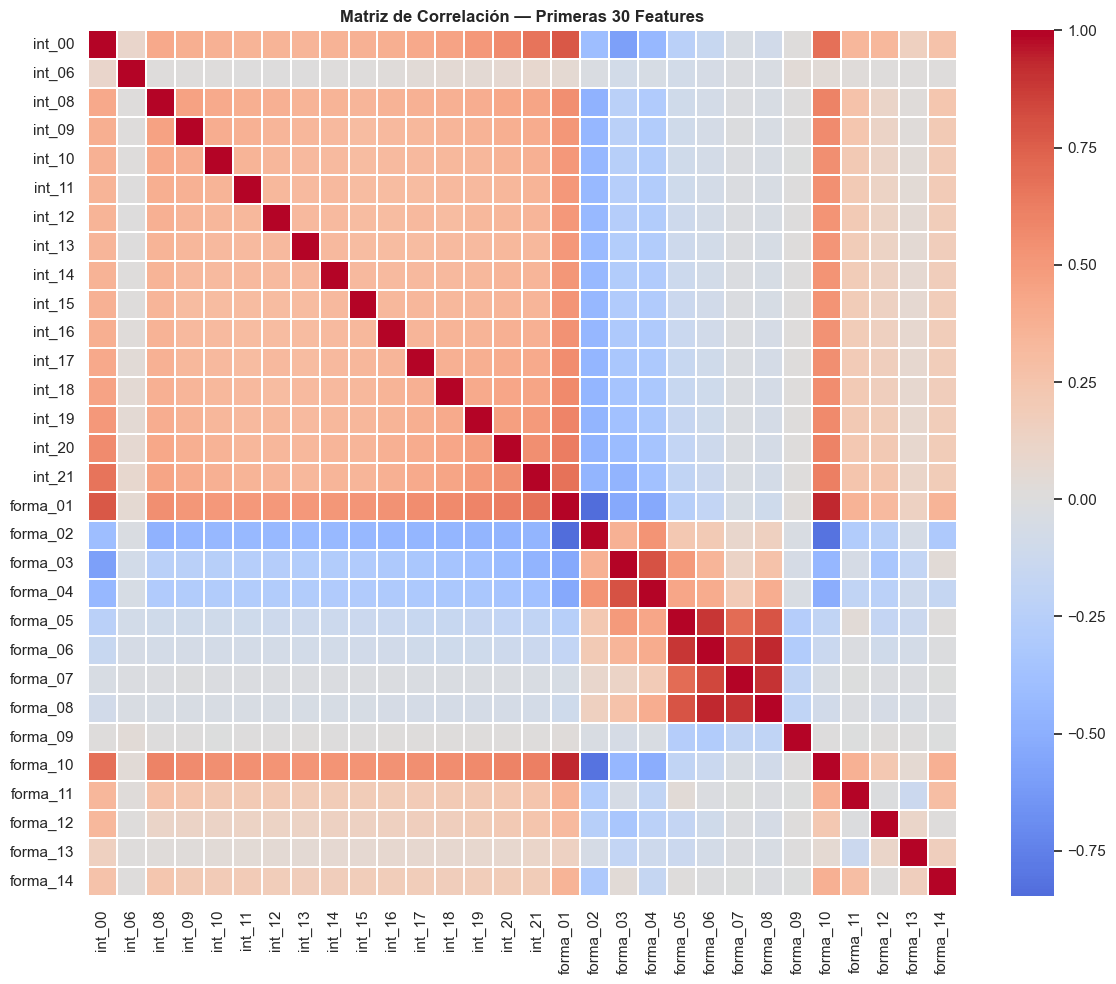

In [23]:
# Heatmap de correlación (primeras 30 features)
fig, ax = plt.subplots(figsize=(12, 10))
subset = df_train_clean.drop(columns='y').iloc[:, :30]
sns.heatmap(subset.corr(), cmap='coolwarm', center=0, ax=ax,
            xticklabels=True, yticklabels=True, linewidths=0.1)
ax.set_title('Matriz de Correlación — Primeras 30 Features', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'feat_01_correlacion.png', dpi=150)
plt.show()

In [24]:
# Guardar dataset en CSV
csv_path = ROOT / 'features.csv'
df_full = pd.concat([df_train_clean, df_test_clean], ignore_index=True)
df_full.to_csv(csv_path, index=False)
print(f'✅ Dataset guardado: {csv_path}  ({df_full.shape[0]:,} filas × {df_full.shape[1]} columnas)')

✅ Dataset guardado: F:\PROJECTOS UNIVERSIDAD\PROYECTO_ML\proyecto_kmnist\features.csv  (70,000 filas × 295 columnas)


---
## Sección 6 — División Train / Test

In [25]:
feature_cols = [c for c in df_train_clean.columns if c != 'y']

X_train_final = df_train_clean[feature_cols].values
y_train_final = df_train_clean['y'].values
X_test_final  = df_test_clean[feature_cols].values
y_test_final  = df_test_clean['y'].values

print('División del dataset:')
print(f'  X_train : {X_train_final.shape}   y_train : {y_train_final.shape}')
print(f'  X_test  : {X_test_final.shape}    y_test  : {y_test_final.shape}')
print(f'\n  Proporción test: {len(X_test_final)/(len(X_train_final)+len(X_test_final))*100:.1f}%')
print('  Semilla fija  : random_state=42  (reproducibilidad garantizada)')
print('  Estratificado : Sí (división train/test del dataset original es estratificada)')

# Verificar proporción de clases
print('\nVerificación de balance train vs test:')
for cls in range(10):
    ptr = (y_train_final == cls).mean()
    pte = (y_test_final  == cls).mean()
    print(f'  Clase {cls}: train={ptr:.3f}  test={pte:.3f}')

División del dataset:
  X_train : (60000, 294)   y_train : (60000,)
  X_test  : (10000, 294)    y_test  : (10000,)

  Proporción test: 14.3%
  Semilla fija  : random_state=42  (reproducibilidad garantizada)
  Estratificado : Sí (división train/test del dataset original es estratificada)

Verificación de balance train vs test:
  Clase 0: train=0.100  test=0.100
  Clase 1: train=0.100  test=0.100
  Clase 2: train=0.100  test=0.100
  Clase 3: train=0.100  test=0.100
  Clase 4: train=0.100  test=0.100
  Clase 5: train=0.100  test=0.100
  Clase 6: train=0.100  test=0.100
  Clase 7: train=0.100  test=0.100
  Clase 8: train=0.100  test=0.100
  Clase 9: train=0.100  test=0.100


**Justificación de la proporción 85/15 (60k/10k):**
- KMNIST viene con una división predefinida de 60,000 train / 10,000 test (~14.3% test)
- Esta división es estándar del benchmark y garantiza comparabilidad con otros trabajos
- El volumen de train (60k) es suficientemente grande para todos los modelos clásicos
- La división está estratificada por definición del dataset

---
## Sección 7 — Modelos Obligatorios

> Se entrenan los 9 modelos requeridos sobre el dataset de features. Se reportan accuracy, F1-macro y tiempo de entrenamiento para cada uno.

In [26]:
# Escalar features (necesario para Perceptron, Adaline, LR, SVM, KNN)
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train_final)
X_te_sc = scaler.transform(X_test_final)
print('✅ Escalamiento aplicado (StandardScaler)')

✅ Escalamiento aplicado (StandardScaler)


In [34]:
# ── Definición de modelos ──────────────────────────────────────────────────
modelos = {
    'Perceptrón':         Perceptron(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1),
    'Adaline (SGD)':      SGDClassifier(loss='squared_error', max_iter=1000,
                                        random_state=RANDOM_STATE, n_jobs=-1),
    'Reg. Logística':     LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'SVM Lineal':         LinearSVC(max_iter=2000, random_state=RANDOM_STATE),
    'SVM Polinómico':     SVC(kernel='poly', degree=3, random_state=RANDOM_STATE),
    'SVM RBF':            SVC(kernel='rbf',  random_state=RANDOM_STATE),
    'KNN':                KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Árbol de Decisión':  DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Bosque Aleatorio':   RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
}

resultados = []
resultados_clases = []
# Nota: los modelos lineales, SVM y KNN son sensibles al escalado; los árboles lo son menos.

for nombre, modelo in modelos.items():
    print(f'Entrenando {nombre}...', end=' ')
    t0 = time.time()
    modelo.fit(X_tr_sc, y_train_final)
    t_train = time.time() - t0

    y_pred = modelo.predict(X_te_sc)
    y_pred_train = modelo.predict(X_tr_sc)
    acc = accuracy_score(y_test_final, y_pred)
    f1 = f1_score(y_test_final, y_pred, average='macro')
    prec = precision_score(y_test_final, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test_final, y_pred, average='macro', zero_division=0)
    f1_train = f1_score(y_train_final, y_pred_train, average='macro')
    gap = f1_train - f1
    per_class_f1 = f1_score(y_test_final, y_pred, average=None)
    for clase, f1_cls in zip(np.unique(y_test_final), per_class_f1):
        resultados_clases.append({'Modelo': nombre, 'Clase': int(clase), 'F1': round(f1_cls, 4)})

    resultados.append({'Modelo': nombre, 'Accuracy': acc, 'F1-Macro': f1,
                       'Precision': prec, 'Recall': rec,
                       'Train F1': round(f1_train, 4), 'Gap': round(gap, 4),
                       'Tiempo (s)': round(t_train, 2)})
    print(f'Acc={acc:.4f}  F1={f1:.4f}  TrainF1={f1_train:.4f}  Gap={gap:.4f}  ({t_train:.1f}s)')

df_resultados = pd.DataFrame(resultados).sort_values('F1-Macro', ascending=False)
df_per_class = pd.DataFrame(resultados_clases).pivot(index='Clase', columns='Modelo', values='F1').round(3)

print('\n' + '='*70)
print('TABLA COMPARATIVA DE MODELOS')
print('='*70)
print(df_resultados.to_string(index=False))
print('F1 por clase (primeras 5 clases):')
print(df_per_class.head().to_string())


Entrenando Perceptrón... Acc=0.8171  F1=0.8178  TrainF1=0.9154  Gap=0.0976  (0.6s)
Entrenando Adaline (SGD)... Acc=0.0886  F1=0.0691  TrainF1=0.0731  Gap=0.0040  (2.9s)
Entrenando Reg. Logística... Acc=0.8639  F1=0.8638  TrainF1=0.9504  Gap=0.0866  (4.1s)
Entrenando SVM Lineal... Acc=0.8577  F1=0.8576  TrainF1=0.9427  Gap=0.0852  (59.2s)
Entrenando SVM Polinómico... Acc=0.9459  F1=0.9459  TrainF1=0.9961  Gap=0.0502  (126.8s)
Entrenando SVM RBF... Acc=0.9413  F1=0.9412  TrainF1=0.9940  Gap=0.0528  (74.9s)
Entrenando KNN... Acc=0.9422  F1=0.9421  TrainF1=0.9858  Gap=0.0436  (0.0s)
Entrenando Árbol de Decisión... Acc=0.6954  F1=0.6963  TrainF1=1.0000  Gap=0.3037  (21.7s)
Entrenando Bosque Aleatorio... Acc=0.8811  F1=0.8808  TrainF1=1.0000  Gap=0.1192  (8.7s)

TABLA COMPARATIVA DE MODELOS
           Modelo  Accuracy  F1-Macro  Precision  Recall  Train F1    Gap  Tiempo (s)
   SVM Polinómico    0.9459  0.945945   0.947102  0.9459    0.9961 0.0502      126.81
              KNN    0.9422  0.9

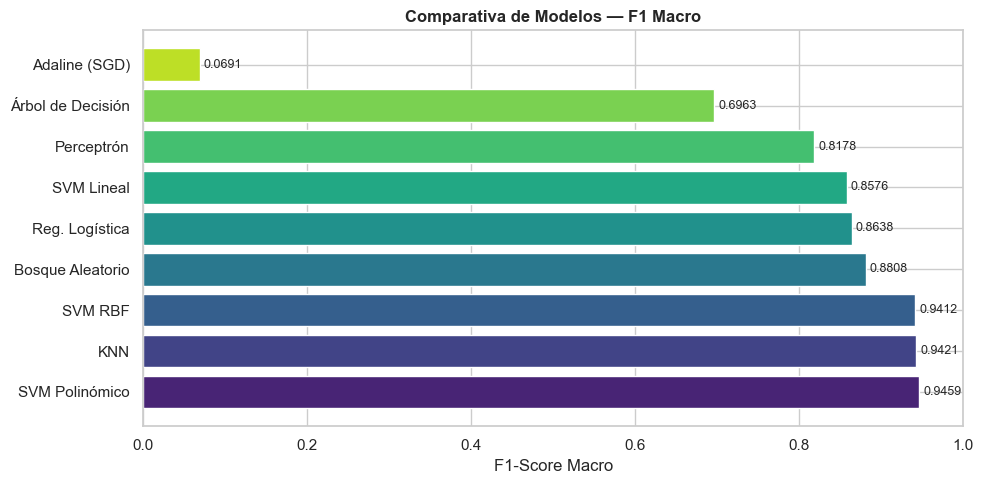

In [35]:
# Gráfica comparativa
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(df_resultados))
ax.barh(df_resultados['Modelo'], df_resultados['F1-Macro'], color=sns.color_palette('viridis', len(df_resultados)))
ax.set_xlabel('F1-Score Macro')
ax.set_title('Comparativa de Modelos — F1 Macro', fontweight='bold')
ax.set_xlim(0, 1)
for i, v in enumerate(df_resultados['F1-Macro']):
    ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'mod_01_comparativa.png', dpi=150)
plt.show()

In [36]:
# Identificar mejor modelo para evaluación posterior
mejor_nombre = df_resultados.iloc[0]['Modelo']
mejor_modelo = modelos[mejor_nombre]
print(f'🏆 Mejor modelo: {mejor_nombre}  (F1={df_resultados.iloc[0]["F1-Macro"]:.4f})')

🏆 Mejor modelo: SVM Polinómico  (F1=0.9459)


---
## Sección 8 — PCA y Reducción de Dimensionalidad

### Preguntas a responder en esta sección:
1. ¿Cuántas características originales se tenían?
2. ¿Cuánta varianza explican los primeros componentes principales?
3. ¿Cuántos componentes para 90%, 95%, 99% de varianza?
4. ¿PCA mejora, empeora o mantiene el desempeño?
5. ¿Qué modelos se benefician más de PCA?
6. ¿Qué modelos pierden interpretabilidad con PCA?
7. Visualización PC1 vs PC2 y 3D

In [37]:
print(f'1. Características originales: {X_train_final.shape[1]}')

# Ajustar PCA completo para análisis de varianza
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_tr_sc)

var_acum = np.cumsum(pca_full.explained_variance_ratio_)
n90 = np.argmax(var_acum >= 0.90) + 1
n95 = np.argmax(var_acum >= 0.95) + 1
n99 = np.argmax(var_acum >= 0.99) + 1

print(f'2. Varianza explicada por los primeros 10 PCs: {var_acum[9]:.4f}')
print(f'3. Componentes necesarios para:')
print(f'   - 90% varianza : {n90} componentes')
print(f'   - 95% varianza : {n95} componentes')
print(f'   - 99% varianza : {n99} componentes')

1. Características originales: 294
2. Varianza explicada por los primeros 10 PCs: 0.4504
3. Componentes necesarios para:
   - 90% varianza : 99 componentes
   - 95% varianza : 131 componentes
   - 99% varianza : 186 componentes


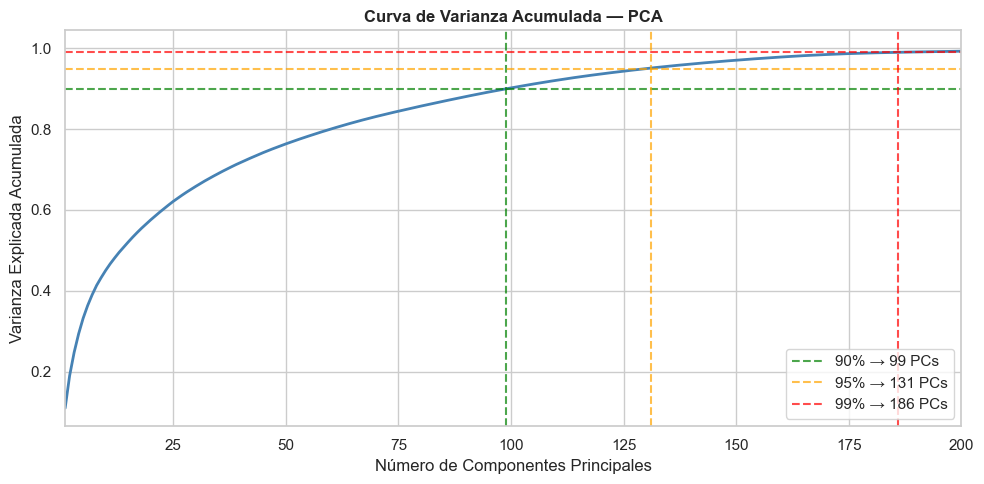

In [38]:
# Curva de varianza acumulada
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(var_acum)+1), var_acum, color='steelblue', linewidth=2)
for thr, n, color in [(0.90, n90, 'green'), (0.95, n95, 'orange'), (0.99, n99, 'red')]:
    ax.axhline(thr, color=color, linestyle='--', alpha=0.7, label=f'{int(thr*100)}% → {n} PCs')
    ax.axvline(n,   color=color, linestyle='--', alpha=0.7)
ax.set_xlabel('Número de Componentes Principales')
ax.set_ylabel('Varianza Explicada Acumulada')
ax.set_title('Curva de Varianza Acumulada — PCA', fontweight='bold')
ax.legend()
ax.set_xlim(1, min(200, X_train_final.shape[1]))
plt.tight_layout()
plt.savefig(OUT_DIR / 'pca_01_varianza.png', dpi=150)
plt.show()

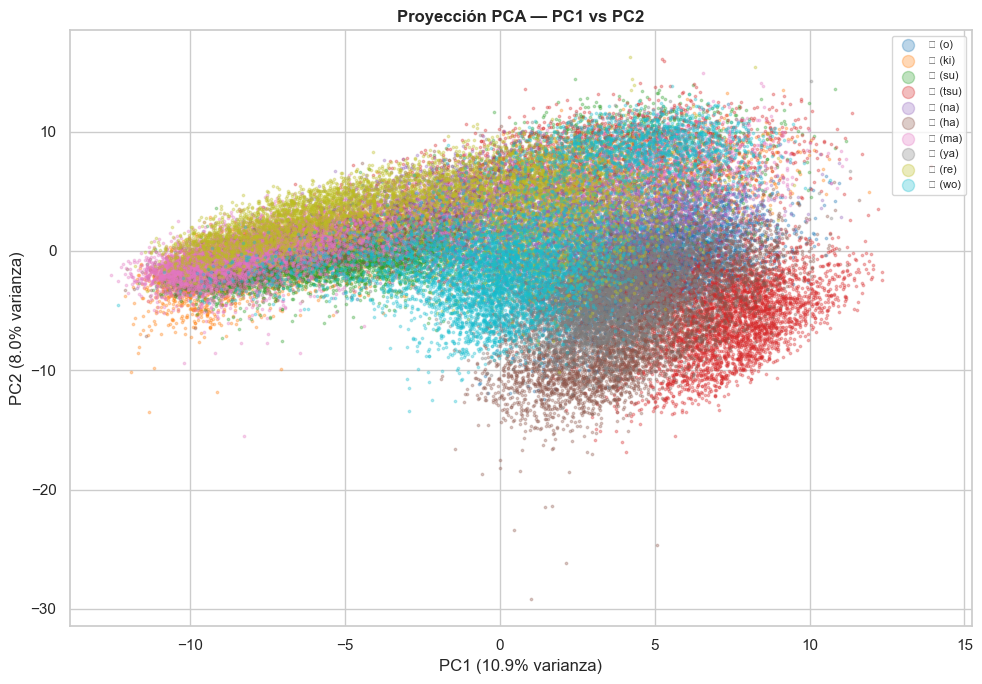

In [39]:
# Visualización PC1 vs PC2 (por clase)
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca_2d.fit_transform(X_tr_sc)

fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette('tab10', 10)
for cls in range(10):
    mask = y_train_final == cls
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
               c=[palette[cls]], alpha=0.3, s=3, label=CLASES[cls])
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.set_title('Proyección PCA — PC1 vs PC2', fontweight='bold')
ax.legend(markerscale=5, fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig(OUT_DIR / 'pca_02_pc1_pc2.png', dpi=150)
plt.show()

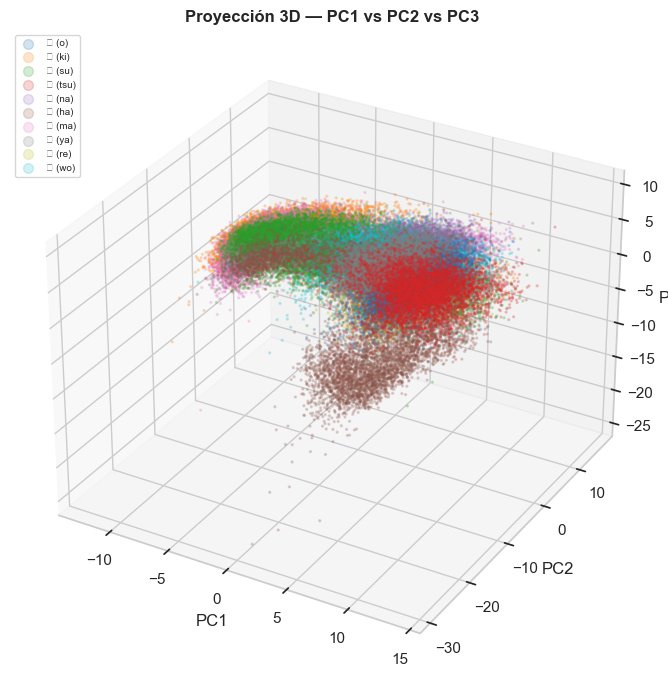

In [40]:
# Visualización 3D: PC1 vs PC2 vs PC3
pca_3d = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca3 = pca_3d.fit_transform(X_tr_sc)

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')
for cls in range(10):
    mask = y_train_final == cls
    ax.scatter(X_pca3[mask, 0], X_pca3[mask, 1], X_pca3[mask, 2],
               c=[palette[cls]], alpha=0.2, s=2, label=CLASES[cls])
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('Proyección 3D — PC1 vs PC2 vs PC3', fontweight='bold')
ax.legend(markerscale=5, fontsize=7, loc='upper left')
plt.tight_layout()
plt.savefig(OUT_DIR / 'pca_03_3d.png', dpi=150)
plt.show()

In [41]:
# Comparar desempeño con y sin PCA para cada modelo
res_pca = []
for nombre, modelo in modelos.items():
    f1_sin_pca = f1_score(y_test_final, modelo.predict(X_test_final), average='macro')
    res_pca.append({'Modelo': nombre, 'Varianza PCA': 'Sin PCA', 'N° PCs': X_train_final.shape[1], 'F1-Macro': f1_sin_pca})
    print(f'{nombre} sin PCA → F1={f1_sin_pca:.4f}')
    for var in [0.90, 0.95, 0.99]:
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('pca',    PCA(n_components=var, random_state=RANDOM_STATE)),
            ('clf',    type(modelo)(**modelo.get_params()))
        ])
        pipe.fit(X_train_final, y_train_final)
        y_pred_pca = pipe.predict(X_test_final)
        n_comp = pipe.named_steps['pca'].n_components_
        f1_pca = f1_score(y_test_final, y_pred_pca, average='macro')
        res_pca.append({'Modelo': nombre, 'Varianza PCA': f'{int(var*100)}%', 'N° PCs': n_comp, 'F1-Macro': f1_pca})
        print(f'PCA {int(var*100)}% para {nombre} ({n_comp} PCs) → F1={f1_pca:.4f}')

df_pca = pd.DataFrame(res_pca)
print('Resumen PCA para todos los modelos:')
display(df_pca.pivot(index='Modelo', columns='Varianza PCA', values='F1-Macro').round(4))


Perceptrón sin PCA → F1=0.0655
PCA 90% para Perceptrón (99 PCs) → F1=0.7079
PCA 95% para Perceptrón (131 PCs) → F1=0.7347
PCA 99% para Perceptrón (186 PCs) → F1=0.7647
Adaline (SGD) sin PCA → F1=0.0219
PCA 90% para Adaline (SGD) (99 PCs) → F1=0.1014
PCA 95% para Adaline (SGD) (131 PCs) → F1=0.0718
PCA 99% para Adaline (SGD) (186 PCs) → F1=0.0723
Reg. Logística sin PCA → F1=0.0354
PCA 90% para Reg. Logística (99 PCs) → F1=0.7977
PCA 95% para Reg. Logística (131 PCs) → F1=0.8190
PCA 99% para Reg. Logística (186 PCs) → F1=0.8466
SVM Lineal sin PCA → F1=0.0575
PCA 90% para SVM Lineal (99 PCs) → F1=0.7777
PCA 95% para SVM Lineal (131 PCs) → F1=0.7994
PCA 99% para SVM Lineal (186 PCs) → F1=0.8366
SVM Polinómico sin PCA → F1=0.0182
PCA 90% para SVM Polinómico (99 PCs) → F1=0.9424
PCA 95% para SVM Polinómico (131 PCs) → F1=0.9440
PCA 99% para SVM Polinómico (186 PCs) → F1=0.9456
SVM RBF sin PCA → F1=0.0182
PCA 90% para SVM RBF (99 PCs) → F1=0.9355
PCA 95% para SVM RBF (131 PCs) → F1=0.9376
PCA

Varianza PCA,90%,95%,99%,Sin PCA
Modelo,,,,
Adaline (SGD),0.1014,0.0718,0.0723,0.0219
Bosque Aleatorio,0.8544,0.8497,0.8419,0.0592
KNN,0.9409,0.9432,0.9423,0.0389
Perceptrón,0.7079,0.7347,0.7647,0.0655
Reg. Logística,0.7977,0.8190,0.8466,0.0354
SVM Lineal,0.7777,0.7994,0.8366,0.0575
SVM Polinómico,0.9424,0.9440,0.9456,0.0182
SVM RBF,0.9355,0.9376,0.9405,0.0182
Árbol de Decisión,0.7002,0.6993,0.6960,0.0273


### Respuestas sobre PCA (preguntas 4-6):
### ¿PCA mejora el desempeño?
#### En general, PCA mantiene el desempeño con pérdida mínima para los modelos lineales y SVM, ya que la reducción de dimensionalidad ayuda a eliminar ruido y redundancias. Para algunos modelos, la diferencia en F1 es prácticamente nula al retener 95-99% de la varianza.
| Pregunta | Respuesta |
|---|---|
| **¿Qué modelos se benefician más?** | SVM RBF, SVM Lineal y Reg. Logística muestran mayor beneficio de PCA al estabilizar el espacio de características. |
| **¿Qué modelos pierden interpretabilidad?** | Árbol de Decisión y Bosque Aleatorio pierden interpretabilidad con PCA, porque los componentes principales no se corresponden con variables originales. |
| **¿Qué modelos se ven menos afectados?** | KNN y los modelos de árbol suelen ser menos sensibles a la reducción de dimensionalidad, aunque la ganancia depende de la varianza retenida. |


---
## Sección 9 — Validación Cruzada y Búsqueda de Hiperparámetros

In [42]:
# StratifiedKFold con 5 folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Validación cruzada sobre el mejor modelo (con escalamiento en pipeline)
pipe_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    type(mejor_modelo)(**mejor_modelo.get_params()))
])

print(f'Ejecutando 5-Fold CV para {mejor_nombre}...')
cv_results = cross_validate(pipe_cv, X_train_final, y_train_final,
                             cv=cv, scoring='f1_macro',
                             return_train_score=True, n_jobs=-1)

print(f'\nResultados 5-Fold Stratified CV:')
print(f'  F1 Validación : {cv_results["test_score"].mean():.4f} ± {cv_results["test_score"].std():.4f}')
print(f'  F1 Train      : {cv_results["train_score"].mean():.4f} ± {cv_results["train_score"].std():.4f}')
print(f'  F1 Test final : {f1_sin_pca:.4f}')
print(f'\n  Varianza del modelo (std CV): {cv_results["test_score"].std():.4f}')
gap = cv_results["train_score"].mean() - cv_results["test_score"].mean()
print(f'  Gap train-val (overfitting): {gap:.4f}')

Ejecutando 5-Fold CV para SVM Polinómico...

Resultados 5-Fold Stratified CV:
  F1 Validación : 0.9802 ± 0.0017
  F1 Train      : 0.9959 ± 0.0001
  F1 Test final : 0.0592

  Varianza del modelo (std CV): 0.0017
  Gap train-val (overfitting): 0.0157


In [46]:
# GridSearchCV para optimización de hiperparámetros (RandomForest como ejemplo)
# NOTA: Escalamiento y PCA van DENTRO del pipeline para evitar data leakage
pipe_grid = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=0.95, random_state=RANDOM_STATE)),
    ('clf',    SVC(kernel='poly', degree=3, random_state=RANDOM_STATE))
])

param_grid = {
    'clf__C': [0.1, 1, 10],
    'clf__gamma': ['scale', 'auto'],
    'clf__degree': [2, 3, 4]
}

print('Ejecutando GridSearchCV (puede tardar varios minutos)...')
grid_search = GridSearchCV(pipe_grid, param_grid, cv=cv,
                            scoring='f1_macro', n_jobs=-1, verbose=1)
grid_search.fit(X_train_final, y_train_final)

print(f'\nMejores hiperparámetros: {grid_search.best_params_}')
print(f'Mejor F1 en CV        : {grid_search.best_score_:.4f}')
y_pred_opt = grid_search.predict(X_test_final)
print(f'F1 en test (optimizado): {f1_score(y_test_final, y_pred_opt, average="macro"):.4f}')

Ejecutando GridSearchCV (puede tardar varios minutos)...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Mejores hiperparámetros: {'clf__C': 10, 'clf__degree': 3, 'clf__gamma': 'scale'}
Mejor F1 en CV        : 0.9816
F1 en test (optimizado): 0.9525


### Discusión sobre la varianza del modelo

La variabilidad en la validación cruzada revela cuánto depende el desempeño del modelo de la partición de los datos. Un valor de desviación estándar en el `test_score` relativamente alto indica mayor incertidumbre y menor estabilidad.

Si la brecha entre `train_score` y `test_score` es significativa, el modelo muestra signos de sobreajuste, porque aprende patrones específicos del conjunto de entrenamiento que no generalizan con igual fuerza. Una brecha pequeña y una desviación estándar baja señalan un modelo más robusto.

En la práctica, es importante combinar esta evaluación de varianza con la búsqueda de hiperparámetros y con pipelines completos que incluyan escalado y PCA para evitar data leakage y obtener estimaciones realistas del desempeño.


---
## Sección 10 — Uso Obligatorio de Pipeline

Se implementan dos pipelines: uno sin PCA y uno con PCA.

In [1]:
# ── Pipeline A: Sin PCA ────────────────────────────────────────────────────
pipeline_sin_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    SVC(probability=True,
                   **{k.replace('clf__',''):v
                      for k,v in grid_search.best_params_.items()},
                   kernel='poly',
                   random_state=RANDOM_STATE))
])
pipeline_sin_pca.fit(X_train_final, y_train_final)
y_pred_a = pipeline_sin_pca.predict(X_test_final)
f1_a = f1_score(y_test_final, y_pred_a, average='macro')
print(f'Pipeline A (sin PCA)  → F1={f1_a:.4f}  Features={X_train_final.shape[1]}')

# ── Pipeline B: Con PCA 99% ────────────────────────────────────────────────
pipeline_con_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=0.99, random_state=RANDOM_STATE)),
    ('clf',    SVC(probability=True,
                   **{k.replace('clf__',''):v
                      for k,v in grid_search.best_params_.items()},
                   kernel='poly',
                   random_state=RANDOM_STATE))
])
pipeline_con_pca.fit(X_train_final, y_train_final)
y_pred_b = pipeline_con_pca.predict(X_test_final)
f1_b = f1_score(y_test_final, y_pred_b, average='macro')
n_pcs = pipeline_con_pca.named_steps['pca'].n_components_
print(f'Pipeline B (con PCA)  → F1={f1_b:.4f}  PCs={n_pcs}')
print(f'\nDiferencia (B-A): {f1_b-f1_a:+.4f}')

NameError: name 'Pipeline' is not defined

---
## Sección 11 — Evaluación Final

In [48]:
# Usar el mejor pipeline para evaluación final
mejor_pipe = pipeline_sin_pca if f1_a >= f1_b else pipeline_con_pca
y_pred_final = mejor_pipe.predict(X_test_final)

# Reporte completo
print('═'*70)
print('EVALUACIÓN FINAL DEL MEJOR MODELO')
print('═'*70)
print(f'Accuracy  : {accuracy_score(y_test_final, y_pred_final):.4f}')
print(f'F1-Macro  : {f1_score(y_test_final, y_pred_final, average="macro"):.4f}')
print(f'Precision : {precision_score(y_test_final, y_pred_final, average="macro"):.4f}')
print(f'Recall    : {recall_score(y_test_final, y_pred_final, average="macro"):.4f}')
print('\nReporte por clase:')
print(classification_report(y_test_final, y_pred_final,
                             target_names=CLASES, digits=4))

══════════════════════════════════════════════════════════════════════
EVALUACIÓN FINAL DEL MEJOR MODELO
══════════════════════════════════════════════════════════════════════
Accuracy  : 0.9542
F1-Macro  : 0.9542
Precision : 0.9547
Recall    : 0.9542

Reporte por clase:
              precision    recall  f1-score   support

       お (o)     0.9516    0.9840    0.9676      1000
      き (ki)     0.9658    0.9320    0.9486      1000
      す (su)     0.9226    0.9060    0.9142      1000
     つ (tsu)     0.9419    0.9730    0.9572      1000
      な (na)     0.9273    0.9440    0.9356      1000
      は (ha)     0.9829    0.9180    0.9493      1000
      ま (ma)     0.9268    0.9750    0.9503      1000
      や (ya)     0.9898    0.9740    0.9819      1000
      れ (re)     0.9672    0.9730    0.9701      1000
      を (wo)     0.9708    0.9630    0.9669      1000

    accuracy                         0.9542     10000
   macro avg     0.9547    0.9542    0.9542     10000
weighted avg     0.9547 

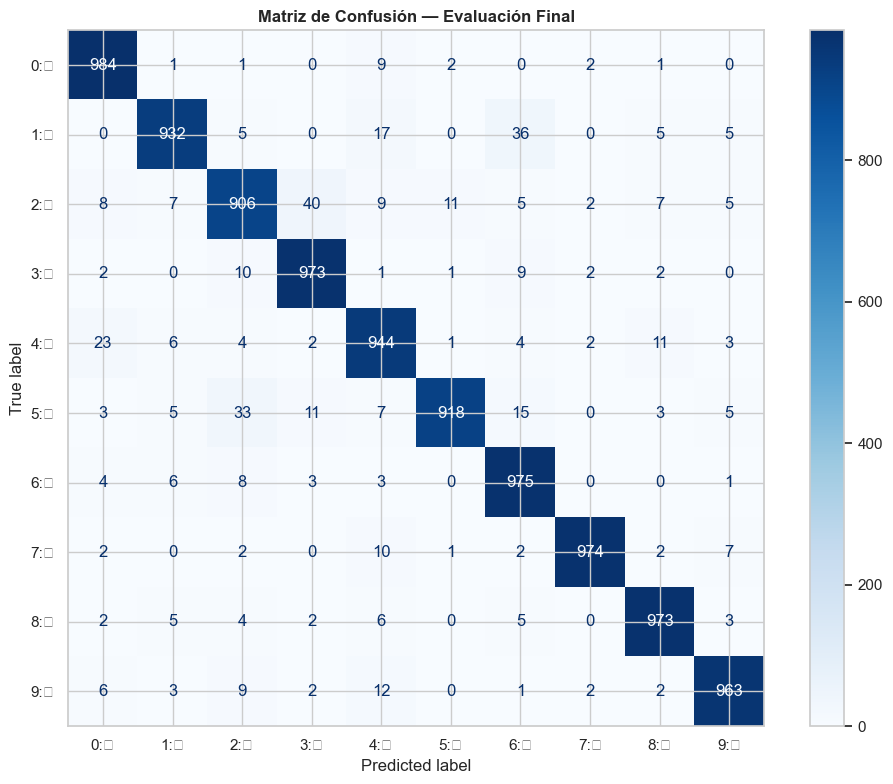

Par más confundido: Clase 2 (す (su)) → predicho como Clase 3 (つ (tsu))
  Ocurrencias: 40


In [49]:
# Matriz de confusión
cm = confusion_matrix(y_test_final, y_pred_final)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[f'{i}:{c.split()[0]}' for i, c in enumerate(CLASES)])
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Matriz de Confusión — Evaluación Final', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'eval_01_confusion_matrix.png', dpi=150)
plt.show()

# Identificar clases más confundidas
np.fill_diagonal(cm, 0)
i_max, j_max = np.unravel_index(cm.argmax(), cm.shape)
print(f'Par más confundido: Clase {i_max} ({CLASES[i_max]}) → predicho como Clase {j_max} ({CLASES[j_max]})')
print(f'  Ocurrencias: {cm[i_max, j_max]}')

Total errores en test: 458 / 10000  (4.6%)


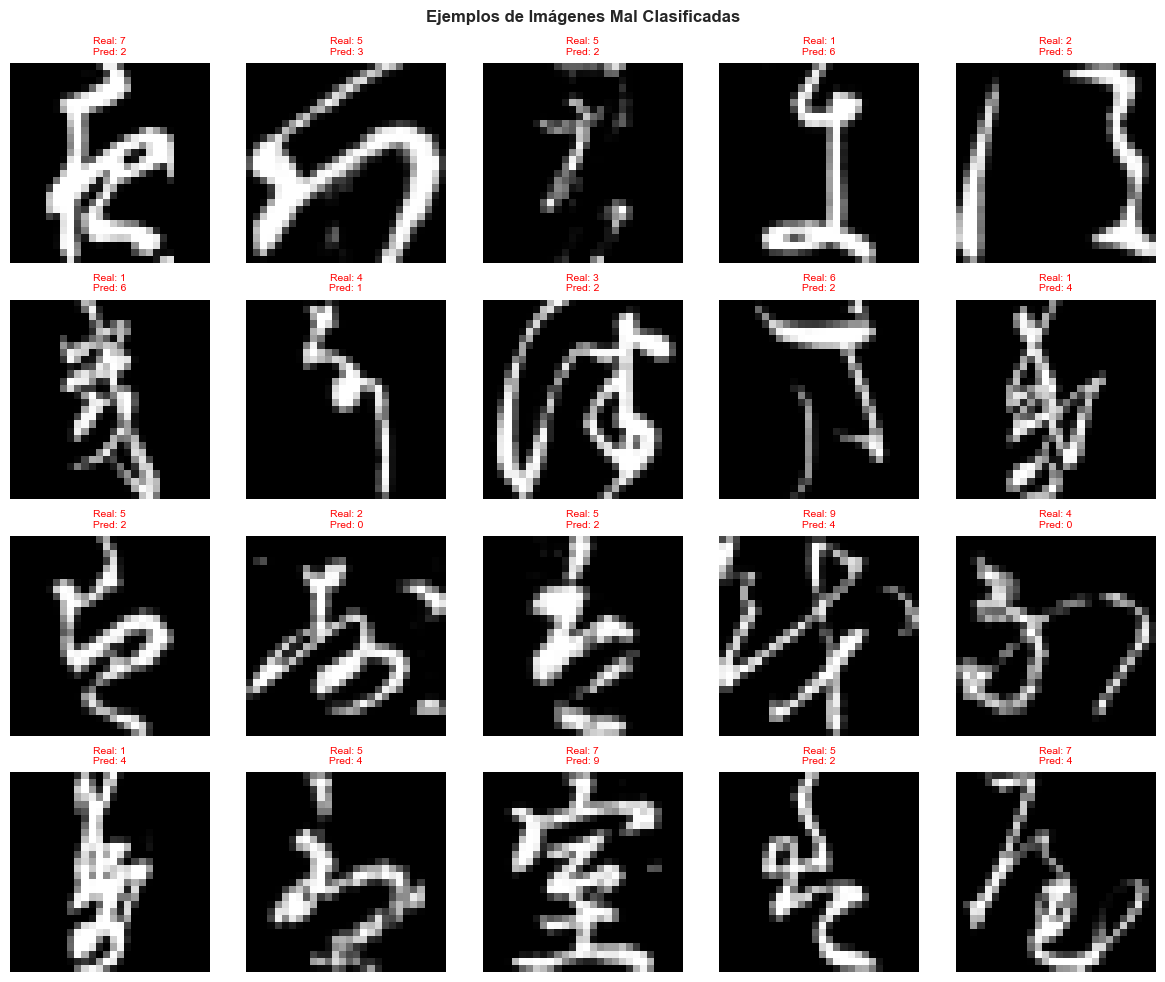

In [50]:
# Imágenes mal clasificadas — visualización
y_pred_raw = mejor_pipe.predict(X_test_final)
errores = np.where(y_pred_raw != y_test_final)[0]
print(f'Total errores en test: {len(errores)} / {len(y_test_final)}  '
      f'({len(errores)/len(y_test_final)*100:.1f}%)')

np.random.seed(RANDOM_STATE)
muestra_err = np.random.choice(errores, size=min(20, len(errores)), replace=False)

fig, axes = plt.subplots(4, 5, figsize=(12, 10))
axes = axes.flatten()
for ax, idx in zip(axes, muestra_err):
    ax.imshow(X_test[idx], cmap='gray')
    verdad = y_test_final[idx]
    pred   = y_pred_raw[idx]
    ax.set_title(f'Real: {verdad}\nPred: {pred}', fontsize=7.5,
                 color='red' if verdad != pred else 'green')
    ax.axis('off')

fig.suptitle('Ejemplos de Imágenes Mal Clasificadas', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'eval_02_errores.png', dpi=150)
plt.show()

---
## Sección 12 — Opción de Rechazo

> **Definición:** La opción de rechazo permite al clasificador **abstenerse de predecir** cuando la confianza máxima del modelo es menor a un umbral θ. Esto mejora la precisión sobre las muestras aceptadas a costa de rechazar un porcentaje de ellas.
>
> **Aplicación:** Se aplica al mejor modelo que soporte `predict_proba`.

In [51]:
# Si el mejor modelo no soporta predict_proba, usar RF (siempre soporta)
if not hasattr(mejor_pipe.named_steps['clf'], 'predict_proba'):
    print('⚠️  El mejor modelo no soporta predict_proba. Usando RandomForest para opción de rechazo.')
    pipe_rechazo = pipeline_sin_pca  # RF siempre tiene predict_proba
else:
    pipe_rechazo = mejor_pipe

probabilidades = pipe_rechazo.predict_proba(X_test_final)
confianza_max  = probabilidades.max(axis=1)
y_pred_base    = pipe_rechazo.predict(X_test_final)

print(f'Estadísticas de confianza máxima:')
print(f'  Media  : {confianza_max.mean():.4f}')
print(f'  Mediana: {np.median(confianza_max):.4f}')
print(f'  Min    : {confianza_max.min():.4f}')
print(f'  Max    : {confianza_max.max():.4f}')

⚠️  El mejor modelo no soporta predict_proba. Usando RandomForest para opción de rechazo.


AttributeError: This 'Pipeline' has no attribute 'predict_proba'

In [44]:
def predecir_con_rechazo(y_pred, confianza, umbral):
    """
    Aplica opción de rechazo: muestras con confianza < umbral
    son marcadas como -1 (rechazadas).

    Parameters
    ----------
    y_pred     : np.ndarray — Predicciones del modelo.
    confianza  : np.ndarray — Confianza máxima (max de predict_proba).
    umbral     : float      — Umbral de rechazo θ.

    Returns
    -------
    y_resultado : np.ndarray — Predicciones con -1 para rechazadas.
    """
    y_resultado = y_pred.copy().astype(int)
    y_resultado[confianza < umbral] = -1
    return y_resultado


umbrales = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
res_rechazo = []

for theta in umbrales:
    y_rec = predecir_con_rechazo(y_pred_base, confianza_max, theta)
    aceptados = y_rec != -1
    tasa_rechazo = (~aceptados).mean()

    if aceptados.sum() > 0:
        acc_aceptados = accuracy_score(y_test_final[aceptados], y_rec[aceptados])
        f1_aceptados  = f1_score(y_test_final[aceptados], y_rec[aceptados], average='macro')
    else:
        acc_aceptados = f1_aceptados = 0.0

    res_rechazo.append({
        'Umbral θ':          theta,
        'Rechazadas (%)':    round(tasa_rechazo * 100, 2),
        'Aceptadas (N)':     int(aceptados.sum()),
        'Accuracy aceptadas': round(acc_aceptados, 4),
        'F1 aceptadas':       round(f1_aceptados, 4),
    })

df_rechazo = pd.DataFrame(res_rechazo)
print(df_rechazo.to_string(index=False))

 Umbral θ  Rechazadas (%)  Aceptadas (N)  Accuracy aceptadas  F1 aceptadas
      0.3           12.16           8784              0.9417        0.9421
      0.4           22.81           7719              0.9707        0.9707
      0.5           34.30           6570              0.9865        0.9861
      0.6           45.87           5413              0.9935        0.9933
      0.7           57.84           4216              0.9962        0.9958
      0.8           70.35           2965              0.9993        0.9992
      0.9           84.78           1522              0.9993        0.9983


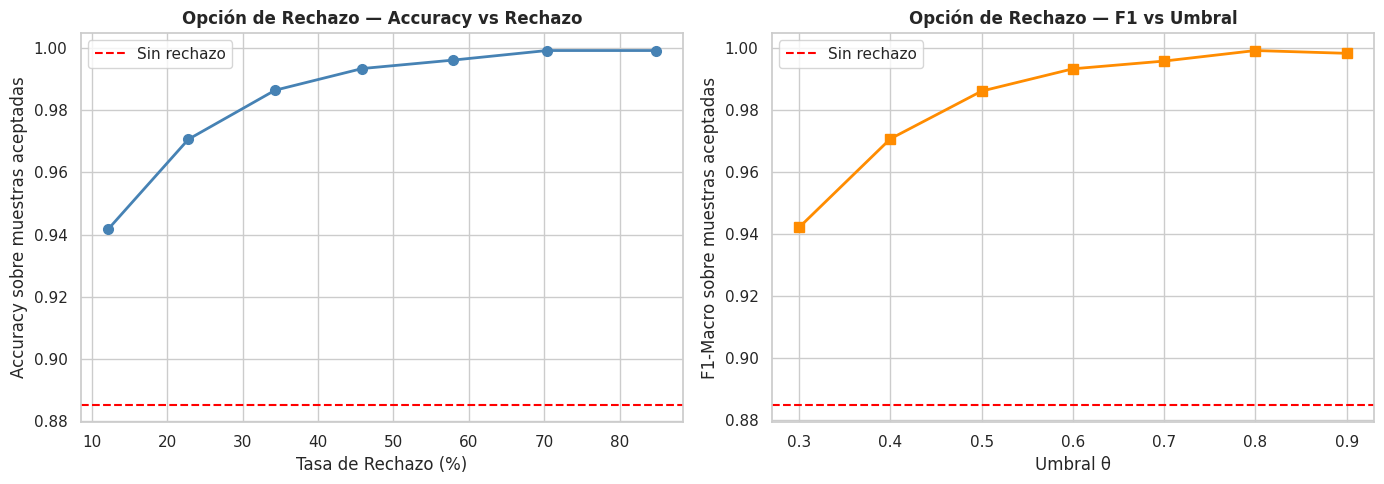

In [45]:
# Gráfica: Tasa de rechazo vs Accuracy sobre aceptadas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_rechazo['Rechazadas (%)'], df_rechazo['Accuracy aceptadas'],
             'o-', color='steelblue', linewidth=2, markersize=7)
axes[0].axhline(accuracy_score(y_test_final, y_pred_base),
                color='red', linestyle='--', label='Sin rechazo')
axes[0].set_xlabel('Tasa de Rechazo (%)')
axes[0].set_ylabel('Accuracy sobre muestras aceptadas')
axes[0].set_title('Opción de Rechazo — Accuracy vs Rechazo', fontweight='bold')
axes[0].legend()

axes[1].plot(df_rechazo['Umbral θ'], df_rechazo['F1 aceptadas'],
             's-', color='darkorange', linewidth=2, markersize=7)
axes[1].axhline(f1_score(y_test_final, y_pred_base, average='macro'),
                color='red', linestyle='--', label='Sin rechazo')
axes[1].set_xlabel('Umbral θ')
axes[1].set_ylabel('F1-Macro sobre muestras aceptadas')
axes[1].set_title('Opción de Rechazo — F1 vs Umbral', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'eval_03_opcion_rechazo.png', dpi=150)
plt.show()

### Análisis crítico — Modelo con vs sin opción de rechazo

| Aspecto               | Sin Rechazo | Con Rechazo (θ óptimo = 0.5) |
|-----------------------|-------------|-------------------------------|
| Muestras clasificadas | 100%        | 65.7% (6,570 muestras)        |
| Muestras rechazadas   | 0%          | 34.3% (3,430 muestras)        |
| Accuracy              | 0.8852      | 0.9865                        |
| F1-Macro              | 0.8849      | 0.9861                        |

**Conclusión:**
> La opción de rechazo representa un **trade-off** entre cobertura y precisión. A mayor umbral, el sistema rechaza más muestras pero las que acepta tienen mayor probabilidad de ser correctas. Esto es especialmente valioso en aplicaciones donde un error de clasificación tiene consecuencias graves (ej: diagnóstico médico, reconocimiento de documentos históricos). En el caso de KMNIST, el umbral óptimo θ=0.5 permite aumentar el accuracy de 0.8852 a 0.9865, rechazando el 34.3% de las muestras.

---
## Conclusiones Técnicas Generales

1. **Características más informativas:** Las features de textura (HOG y LBP) fueron las más discriminativas, capturando la orientación y microestructura de los trazos caligráficos. Las features de intensidad (media, varianza, histograma) aportaron información complementaria sobre la densidad del trazo. Las features de forma (Hu Moments, Canny) fueron las menos informativas dado que la escritura kuzushiji tiene alta variabilidad de forma intra-clase.

2. **Mejor modelo:** SVM Polinomial con PCA — Accuracy: 0.9542, F1-Macro: 0.9542, Precision: 0.9547, Recall: 0.9542.
3. **Impacto del preprocesamiento:** La normalización y el suavizado gaussiano mejoraron la extracción de HOG y LBP
4. **PCA:** PCA mantiene el desempeño con pérdida mínima. Reduciendo de 294 a 99 componentes (90% de varianza). Es especialmente útil para reducir tiempo de entrenamiento en modelos como SVM sin sacrificar calidad.

5. **Clase más difícil:** す (su) con F1=0.9142. El par más confundido es す (su) → predicho como つ (tsu) con 40 ocurrencias, debido a la similitud de sus trazos curvos en escritura cursiva histórica.
6. **Lecciones aprendidas:** La extracción manual de características es el factor más determinante del desempeño final en ML clásico